In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer

In [2]:
data = pd.read_csv('data\kaggle_dataset.csv')
data = data.drop(['ID'], axis=1)
data.dropna(inplace=True)

<>:1: SyntaxWarning: invalid escape sequence '\k'
<>:1: SyntaxWarning: invalid escape sequence '\k'
C:\Users\markham\AppData\Local\Temp\ipykernel_25424\2122403269.py:1: SyntaxWarning: invalid escape sequence '\k'
  data = pd.read_csv('data\kaggle_dataset.csv')


In [3]:
print(data[data['target']==1]['target'].count())
print(data[data['target']==0]['target'].count())

33
1767


In [4]:
# Feature Engineering
X = data.drop(['target'], axis=1)
y = data['target']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

c:\Users\markham\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


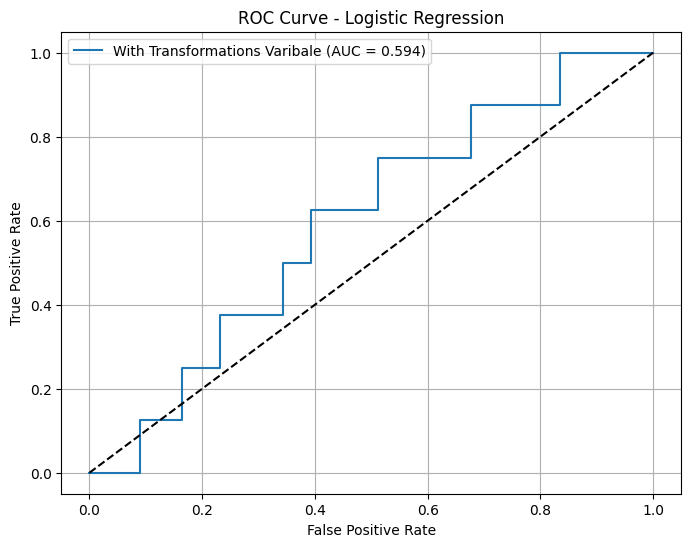

In [5]:
# Train Logistic Regression
log_reg = LogisticRegression(max_iter=10000, random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)  # Use balanced data

# Predictions
y_pred_prob = log_reg.predict_proba(X_test)[:, 1]
# Step 6: Compute ROC and AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
y_pred = (y_pred_prob >= 0.5).astype(int)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'With Transformations Varibale (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='best')
plt.grid(True)
plt.show()

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'class_weight': 'balanced', 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

Optimized Random Forest Results:
AUC Value: 0.3567
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
Key Parameters: {'class_weight': 'balanced', 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


c:\Users\markham\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


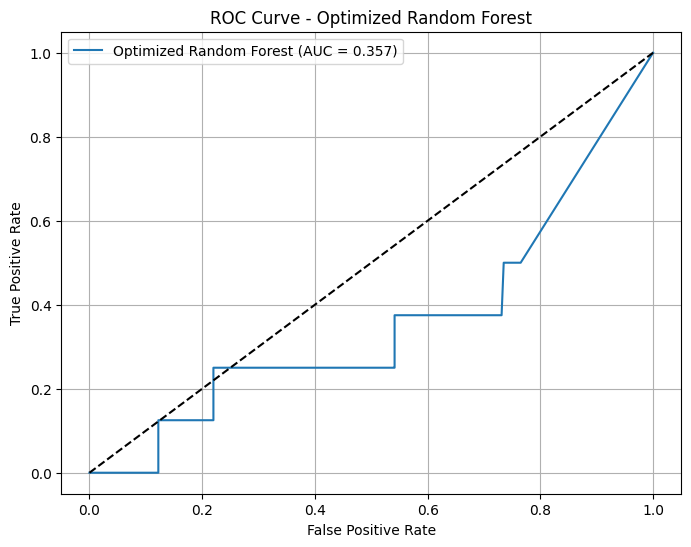

In [6]:
param_grid = {
    'n_estimators': [100, 200, 300],  
    'max_depth': [10, 20, 30, None],  
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 2, 4],    
    'class_weight': ['balanced', None]  
}

rf = RandomForestClassifier(random_state=42)

# get the best hyperparameters use GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)


best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# predict model
y_pred_prob = best_rf.predict_proba(X_test)[:, 1]
y_pred = (y_pred_prob >= 0.5).astype(int)


roc_auc = roc_auc_score(y_test, y_pred_prob)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


print("\nOptimized Random Forest Results:")
print(f"AUC Value: {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Key Parameters: {grid_search.best_params_}")

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Optimized Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Optimized Random Forest')
plt.legend(loc='best')
plt.grid(True)
plt.show()